# Module 5 Lab: Crafting and Detecting Adversarial Attacks

**Practical Machine Learning Foundations**

**Purpose:** train an image classifier, break it with adversarial examples you craft yourself, steal it through its own API, poison it during training, and then build statistical detectors that catch the attacks.

**Date:** 2026-08-24 | **Author:** Nick Garner

Every model in the previous modules was built on an assumption: that the data is honest and the model is private. Attackers do not share that assumption.

The attacks are run on both sides, against a classifier you train yourself, on a laptop, in minutes. That is the point: none of this requires a large budget.

### What you will do

| Section | Focus |
|---|---|
| 1. Train the victim | A CIFAR-10 CNN, the model under attack |
| 2. FGSM | The foundational white-box attack, from gradient to image |
| 3. Visualize perturbations | What an adversarial example actually looks like |
| 4. Stronger attacks | Targeted FGSM and PGD |
| 5. Black-box attacks | Transferability, substitute models, query-based gradient estimation |
| 6. Model extraction | Clone the model through its API, then attack it as white-box |
| 7. Training-time attacks | Label flipping, backdoors, membership inference |
| 8. Detection | Statistical filters that catch adversarial inputs |
| 9. Defenses and deployment | Adversarial training, validation, monitoring, secure serving |

### Before we touch code: threat modeling

Defending starts with knowing what you are defending. ML systems have attack surfaces that traditional application security misses entirely, because data poisoning, model inversion, and adversarial inputs are not in the OWASP Top 10. Running only a standard AppSec review leaves all of them unexamined.

**The ML attack surface, stage by stage:**

| Stage | What an attacker targets |
|---|---|
| Data collection | Poisoning, label manipulation, supply chain compromise of third-party datasets |
| Training pipeline | Backdoor injection, hyperparameter tampering |
| Model artifacts | Weight theft, architecture extraction |
| Inference API | Adversarial inputs, query-based attacks, extraction |
| Deployment environment | Model serving tampering, edge device compromise |
| Feedback loops | Drift exploitation, steering a self-training model off course |

**STRIDE extends naturally to ML**, which is convenient if your team already uses it:

| Traditional STRIDE | ML equivalent |
|---|---|
| Spoofing | Adversarial inputs, making a stop sign look like a speed limit sign |
| Tampering | Data poisoning |
| Repudiation | Unaudited predictions you cannot investigate later |
| Information disclosure | Model inversion, leaking training data through outputs |
| Denial of service | Resource exhaustion against expensive GPU inference |
| Elevation of privilege | Model extraction, gaining full model capability without authorization |

**The threat modeling workflow:** define scope (model only, or the whole pipeline?), identify assets (training data, weights, the prediction API, user data at inference), enumerate threats against each asset, assess risk as likelihood times impact, then define concrete mitigations rather than vague intentions. "Add input validation on the prediction endpoint" is a mitigation; "be more secure" is not.

**MITRE ATLAS** (Adversarial Threat Landscape for AI Systems) is the ATT&CK framework's sibling for adversarial ML, cataloging real incidents such as the Microsoft Tay manipulation and Tesla autopilot evasion, organized as tactics, techniques, and procedures. It is free at atlas.mitre.org and works well as a checklist during a threat modeling session: walk each tactic and ask whether it applies to your system.


## Section 0: Setup

This lab uses PyTorch, which is preinstalled in Colab. A GPU runtime makes it faster but is not required; everything here runs on CPU in a few minutes.


In [1]:
import time, hashlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)


PyTorch 2.11.0+cpu | device: cpu


---
# Section 1: Train the victim model

We need something to attack. CIFAR-10 is the standard benchmark for this work: 60,000 colour images at 32 by 32 pixels across ten classes. We use a subset and a small convolutional network so the whole lab runs quickly.

If the CIFAR-10 download is unavailable, the cell below generates a synthetic stand-in with the same shape and a comparable difficulty level. Every attack in this notebook works identically on either.


In [2]:
USE_CIFAR = True
try:
    import torchvision
    import torchvision.transforms as transforms
    tf = transforms.ToTensor()          # keeps pixels in [0, 1], which FGSM needs
    train_ds = torchvision.datasets.CIFAR10("./data", train=True,
                                            download=True, transform=tf)
    test_ds = torchvision.datasets.CIFAR10("./data", train=False,
                                           download=True, transform=tf)
    CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

    def to_arrays(ds, n):
        idx = torch.randperm(len(ds))[:n]
        Xs = torch.stack([ds[i][0] for i in idx])
        ys = torch.tensor([ds[i][1] for i in idx])
        return Xs, ys

    X_train, y_train = to_arrays(train_ds, 10000)
    X_test, y_test = to_arrays(test_ds, 2000)
    print("Loaded real CIFAR-10.")
except Exception as e:
    USE_CIFAR = False
    print("CIFAR-10 unavailable (" + type(e).__name__ + "). Building a")
    print("synthetic stand-in with the same shape and difficulty.")
    CLASS_NAMES = ["disc", "block", "stripe", "horizon", "grating", "halo"]

    def synth(n_per, sig=0.14, noise=0.32, label_noise=0.10, seed=SEED):
        r = np.random.default_rng(seed)
        yy, xx = np.mgrid[0:32, 0:32]
        Xs, ys = [], []
        for c in range(6):
            for _ in range(n_per):
                img = r.normal(0.45, noise, (3, 32, 32)) + r.normal(0, 0.06)
                if c == 0:
                    m = ((xx - 16 + r.integers(-6, 6)) ** 2 +
                         (yy - 16) ** 2) < r.integers(25, 90); img[0] += sig * m
                elif c == 1:
                    m = ((abs(xx - 16) < r.integers(5, 13)) &
                         (abs(yy - 16) < r.integers(5, 13))); img[1] += sig * m
                elif c == 2:
                    m = np.abs(xx - yy) < r.integers(2, 7); img[2] += sig * m
                elif c == 3:
                    m = yy > r.integers(18, 26)
                    img[0] += sig * .8 * m; img[1] += sig * .8 * m
                elif c == 4:
                    m = (xx % r.integers(4, 9)) < 2; img[2] += sig * .9 * m
                else:
                    m = ((xx - 16) ** 2 + (yy - 16) ** 2) > r.integers(80, 200)
                    img[1] += sig * .7 * m
                Xs.append(img); ys.append(c)
        Xa = np.clip(np.array(Xs), 0, 1).astype(np.float32)
        ya = np.array(ys)
        flip = r.choice(len(ya), int(label_noise * len(ya)), replace=False)
        ya[flip] = r.integers(0, 6, len(flip))    # irreducible label noise
        p = r.permutation(len(ya))
        return torch.tensor(Xa[p]), torch.tensor(ya[p])

    Xa, ya = synth(1400)
    X_train, y_train = Xa[:6720], ya[:6720]
    X_test, y_test = Xa[6720:], ya[6720:]

N_CLASSES = len(CLASS_NAMES)
print("Train:", tuple(X_train.shape), "| Test:", tuple(X_test.shape),
      "|", N_CLASSES, "classes")
print("Pixel range:", float(X_train.min()), "to", float(X_train.max()),
      "<- attacks below assume [0, 1]")


100%|██████████| 170M/170M [39:43<00:00, 71.5kB/s]


Loaded real CIFAR-10.
Train: (10000, 3, 32, 32) | Test: (2000, 3, 32, 32) | 10 classes
Pixel range: 0.0 to 1.0 <- attacks below assume [0, 1]


In [3]:
class SmallCNN(nn.Module):
    """A compact convolutional classifier. Deliberately ordinary."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.c1 = nn.Conv2d(3, 32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.max_pool2d(F.relu(self.c3(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))


def train_model(model, Xtr, ytr, epochs=8, bs=128, lr=1e-3, quiet=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr, ytr = Xtr.to(device), ytr.to(device)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(ytr), device=device)
        for i in range(0, len(ytr), bs):
            b = perm[i:i + bs]
            opt.zero_grad()
            F.cross_entropy(model(Xtr[b]), ytr[b]).backward()
            opt.step()
        if not quiet and (ep + 1) % 4 == 0:
            print("  epoch", ep + 1, "done")
    return model.eval()


@torch.no_grad()
def accuracy(model, Xs, ys, bs=512):
    model.eval()
    correct = 0
    for i in range(0, len(ys), bs):
        xb = Xs[i:i + bs].to(device)
        correct += (model(xb).argmax(1).cpu() == ys[i:i + bs]).sum().item()
    return correct / len(ys)


t0 = time.time()
print("Training the victim model...")
victim = train_model(SmallCNN(N_CLASSES), X_train, y_train, epochs=6)
train_acc = accuracy(victim, X_train, y_train)
test_acc = accuracy(victim, X_test, y_test)
print("\nTrained in", round(time.time() - t0, 1), "seconds")
print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:    ", round(test_acc, 4))
print("Overfitting gap:  ", round(train_acc - test_acc, 4),
      "<- remember this number, Section 7 attacks it directly")


Training the victim model...
  epoch 4 done

Trained in 108.5 seconds
Training accuracy: 0.5263
Test accuracy:     0.5235
Overfitting gap:   0.0028 <- remember this number, Section 7 attacks it directly


That is our victim: an ordinary classifier with unremarkable accuracy, the kind of model that would pass review and ship. Hold onto the test accuracy figure, because the next section reduces it to almost nothing without changing a single pixel in a way you can see.

---
# Section 2: FGSM, the Fast Gradient Sign Method

Published by Goodfellow, Shlens, and Szegedy in 2015, FGSM changed how the field thinks about robustness. The idea is almost impudent.

**During training** we compute the gradient of the loss with respect to the **weights**, then nudge the weights to reduce error. **During FGSM** we compute the gradient of the loss with respect to the **input**, then nudge the input to *increase* error. Same backpropagation, same math, aimed at a different variable and pointed in the opposite direction.

The gradient of the loss with respect to each pixel is effectively a vulnerability report: for every pixel it says whether raising or lowering it would confuse the model more. **The model provides its own attack blueprint.**

The formula:

**x_adv = x + epsilon * sign(gradient of J with respect to x)**

- **x** is the original image
- **epsilon** controls how much each pixel may change
- **sign()** reduces every gradient value to +1 or -1, pure direction with no magnitude, which is what makes the perturbation uniform across pixels
- One step, not an optimization loop. That is the "fast" in Fast Gradient Sign Method.

The final step is clipping back to the valid pixel range, because an image with pixel values outside [0, 1] is not an image.


In [4]:
def fgsm_attack(image, epsilon, data_grad):
    """
    image:     original clean image tensor, pixels in [0, 1]
    epsilon:   perturbation magnitude (the attacker's budget)
    data_grad: gradient of the loss with respect to the input image
    """
    # 1. Direction only: which way does each pixel push the loss up?
    sign_data_grad = data_grad.sign()

    # 2. Take one uniform step in that direction
    perturbed = image + epsilon * sign_data_grad

    # 3. Clip so the result is still a valid image
    return torch.clamp(perturbed, 0, 1)


def get_input_gradients(model, images, labels):
    """Forward pass, loss, backward pass, and read the gradient off the INPUT."""
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    model.zero_grad()
    loss = F.cross_entropy(model(images), labels)
    loss.backward()
    return images.grad.detach()


# Attack one image so the mechanics are visible
i = 7
img, label = X_test[i:i + 1], y_test[i:i + 1]
grad = get_input_gradients(victim, img, label)
adv = fgsm_attack(img.to(device), 0.03, grad)

with torch.no_grad():
    p_clean = F.softmax(victim(img.to(device)), 1)[0]
    p_adv = F.softmax(victim(adv), 1)[0]

print("True class:", CLASS_NAMES[label.item()])
print("Clean prediction:      ", CLASS_NAMES[p_clean.argmax().item()],
      "at", str(round(p_clean.max().item() * 100, 1)) + "% confidence")
print("Adversarial prediction:", CLASS_NAMES[p_adv.argmax().item()],
      "at", str(round(p_adv.max().item() * 100, 1)) + "% confidence")
print()
print("Largest change to any single pixel:",
      round((adv - img.to(device)).abs().max().item(), 4))


True class: bird
Clean prediction:       cat at 31.9% confidence
Adversarial prediction: cat at 43.1% confidence

Largest change to any single pixel: 0.03


### The epsilon tradeoff

Epsilon is the attacker's budget, and choosing it is the attacker's craft:

- **epsilon = 0.0**: no perturbation, the original image
- **epsilon = 0.01**: imperceptible to humans, often already enough to flip predictions
- **epsilon = 0.1**: barely visible noise, high success rate
- **epsilon = 0.3**: visibly distorted, near-certain misclassification

Real attackers use the **smallest** epsilon that reliably works, because that maximizes stealth. Which produces the defender's dilemma: the attacks that succeed with the least perturbation are exactly the ones hardest to detect.

Let's sweep it and watch accuracy collapse.


In [5]:
def fgsm_batch(model, Xs, ys, epsilon, bs=256):
    """Generate FGSM adversarial examples for a whole set."""
    out = []
    for i in range(0, len(ys), bs):
        xb, yb = Xs[i:i + bs], ys[i:i + bs]
        g = get_input_gradients(model, xb, yb)
        out.append(fgsm_attack(xb.to(device), epsilon, g).cpu())
    return torch.cat(out)


EPSILONS = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3]
adv_sets, adv_acc = {}, []
for eps in EPSILONS:
    Xa = X_test if eps == 0 else fgsm_batch(victim, X_test, y_test, eps)
    adv_sets[eps] = Xa
    acc = accuracy(victim, Xa, y_test)
    adv_acc.append(acc)
    print("epsilon", str(eps).ljust(6), "accuracy", round(acc, 4),
          "|", "#" * int(acc * 50))


epsilon 0.0    accuracy 0.5235 | ##########################
epsilon 0.005  accuracy 0.4055 | ####################
epsilon 0.01   accuracy 0.3095 | ###############
epsilon 0.02   accuracy 0.17 | ########
epsilon 0.03   accuracy 0.0965 | ####
epsilon 0.05   accuracy 0.028 | #
epsilon 0.1    accuracy 0.0045 | 
epsilon 0.2    accuracy 0.0 | 
epsilon 0.3    accuracy 0.001 | 


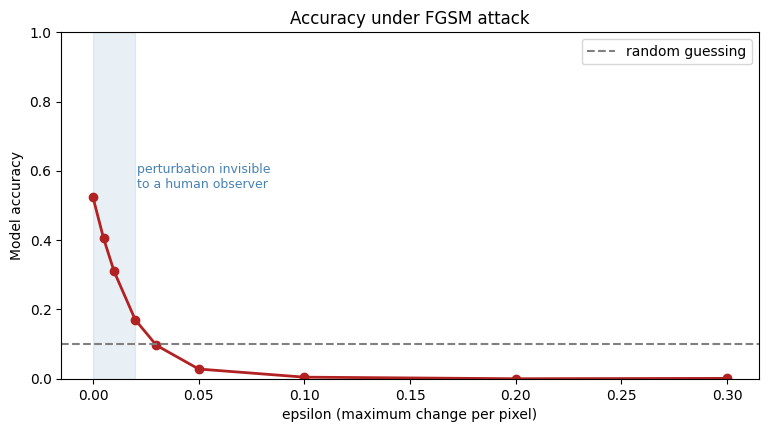

Clean accuracy: 0.5235
At epsilon 0.01 (invisible): 0.3095
At epsilon 0.03: 0.0965


In [6]:
plt.figure(figsize=(9, 4.5))
plt.plot(EPSILONS, adv_acc, "o-", color="firebrick", linewidth=2)
plt.axhline(1.0 / N_CLASSES, linestyle="--", color="gray",
            label="random guessing")
plt.fill_betweenx([0, 1], 0, 0.02, alpha=0.12, color="steelblue")
plt.text(0.021, 0.55, "perturbation invisible\nto a human observer",
         fontsize=9, color="steelblue")
plt.xlabel("epsilon (maximum change per pixel)")
plt.ylabel("Model accuracy")
plt.title("Accuracy under FGSM attack")
plt.ylim(0, 1); plt.legend()
plt.show()

print("Clean accuracy:", round(adv_acc[0], 4))
print("At epsilon 0.01 (invisible):", round(adv_acc[2], 4))
print("At epsilon 0.03:", round(adv_acc[4], 4))


The curve falls off a cliff inside the shaded region, where no human would see anything wrong with the images. That is the entire security argument of this module in one plot: **clean accuracy tells you nothing about adversarial robustness.** A model with excellent test metrics can be driven to near-zero accuracy by changes smaller than JPEG compression artifacts.

If you are using ML for malware detection, fraud detection, or intrusion detection, adversaries will probe your model. Evaluation has to include adversarial testing, not just a held-out set.

---
# Section 3: Visualize the perturbation

The numbers say the attack works. Now look at it.


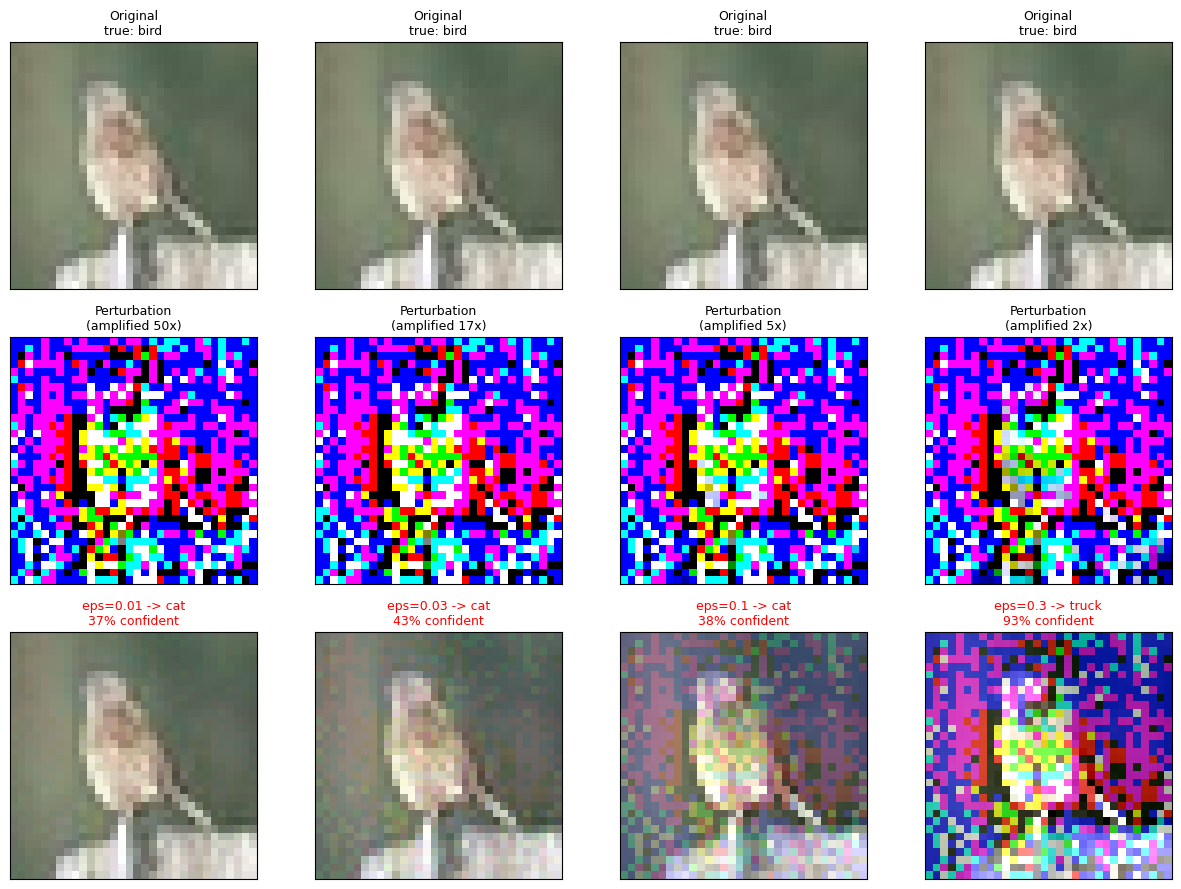

In [7]:
def show_attack_grid(idx, epsilons=(0.01, 0.03, 0.1, 0.3)):
    n = len(epsilons)
    fig, axes = plt.subplots(3, n, figsize=(3.1 * n, 9))
    clean = X_test[idx:idx + 1]
    true_lbl = y_test[idx].item()

    for j, eps in enumerate(epsilons):
        a = adv_sets[eps][idx:idx + 1]
        pert = (a - clean)
        with torch.no_grad():
            p = F.softmax(victim(a.to(device)), 1)[0]
        pred, conf = p.argmax().item(), p.max().item()

        axes[0, j].imshow(clean[0].permute(1, 2, 0).numpy())
        axes[0, j].set_title("Original\ntrue: " + CLASS_NAMES[true_lbl],
                             fontsize=9)

        # Perturbation rescaled to be visible; it is invisible at true scale
        shown = (pert[0].permute(1, 2, 0).numpy() / (2 * eps)) + 0.5
        axes[1, j].imshow(np.clip(shown, 0, 1))
        axes[1, j].set_title("Perturbation\n(amplified " +
                             str(round(1 / (2 * eps))) + "x)", fontsize=9)

        axes[2, j].imshow(a[0].permute(1, 2, 0).numpy())
        colour = "green" if pred == true_lbl else "red"
        axes[2, j].set_title("eps=" + str(eps) + " -> " + CLASS_NAMES[pred] +
                             "\n" + str(round(conf * 100)) + "% confident",
                             fontsize=9, color=colour)
        for r in range(3):
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
    plt.tight_layout(); plt.show()

show_attack_grid(7)


The middle row is the perturbation, **amplified many times over** so it is visible at all. At its true scale it is a faint haze. The bottom row is what the model actually receives, and by the second or third column a human sees an ordinary image while the model has confidently changed its mind.

Note the structure in the perturbation. It is not random noise; it traces edges and textures, because those are the pixels the gradient says matter most.

### Measuring the perturbation

Attackers and defenders both describe perturbation size using **norms**, and the norm you choose defines your threat model:

- **L-infinity** is the maximum change to any single pixel. This is FGSM's natural budget and the most common choice for image models.
- **L2** is the total Euclidean distance of the perturbation across the whole image, capturing overall magnitude rather than worst case.


In [8]:
print("Perturbation size and attack success by epsilon")
print()
print("epsilon   L-inf     L2      accuracy   % misclassified")
for eps in EPSILONS[1:]:
    d = (adv_sets[eps] - X_test).flatten(1)
    linf = d.abs().max(1).values.mean().item()
    l2 = d.norm(dim=1).mean().item()
    acc = accuracy(victim, adv_sets[eps], y_test)
    print(str(eps).ljust(9), str(round(linf, 4)).ljust(9),
          str(round(l2, 3)).ljust(7), str(round(acc, 4)).ljust(10),
          str(round((1 - acc) * 100, 1)) + "%")


Perturbation size and attack success by epsilon

epsilon   L-inf     L2      accuracy   % misclassified
0.005     0.005     0.276   0.4055     59.5%
0.01      0.01      0.551   0.3095     69.0%
0.02      0.02      1.1     0.17       83.0%
0.03      0.03      1.648   0.0965     90.3%
0.05      0.05      2.738   0.028      97.2%
0.1       0.1       5.427   0.0045     99.6%
0.2       0.2       10.597  0.0        100.0%
0.3       0.3       15.378  0.001      99.9%


L-infinity tracks epsilon exactly, which is FGSM working as designed: every pixel moves by the full budget, no more and no less.


---
# Section 4: Stronger attacks

FGSM is one step. Everything stronger builds on the same gradient intuition.

### Targeted FGSM

Plain FGSM maximizes loss toward *any* wrong answer. A targeted attack picks the wrong answer in advance: not just "make the model wrong" but "make the model think this malware is benign." The change is a sign flip, because now we **descend** the loss toward the class we want.


In [9]:
def targeted_fgsm(model, images, target_class, epsilon):
    """Push the prediction toward a chosen class by descending its loss."""
    images = images.clone().detach().to(device).requires_grad_(True)
    target = torch.full((len(images),), target_class,
                        dtype=torch.long, device=device)
    model.zero_grad()
    F.cross_entropy(model(images), target).backward()
    # Note the MINUS: we move toward the target class, not away from truth
    return torch.clamp(images - epsilon * images.grad.sign(), 0, 1).detach()


TARGET = 3
sample = X_test[:200]
adv_t = targeted_fgsm(victim, sample, TARGET, 0.05)
with torch.no_grad():
    preds = victim(adv_t).argmax(1).cpu()

print("Target class:", CLASS_NAMES[TARGET])
print("Images pushed into the target class:",
      str(round((preds == TARGET).float().mean().item() * 100, 1)) + "%")
print("(they started as a mix of all", N_CLASSES, "classes)")


Target class: cat
Images pushed into the target class: 67.0%
(they started as a mix of all 10 classes)


### PGD: iterative FGSM

Projected Gradient Descent takes many small steps instead of one large one, re-projecting back inside the allowed perturbation ball after each step so the total change never exceeds epsilon. It is slower and considerably stronger, and it is the standard benchmark for robustness evaluation. If a defense survives PGD, that claim means something.


In [10]:
def pgd_attack(model, images, labels, epsilon, alpha=None, steps=10):
    """Iterative FGSM with projection back into the epsilon-ball each step."""
    alpha = alpha if alpha is not None else epsilon / 4
    images, labels = images.to(device), labels.to(device)
    adv = images.clone().detach()
    for _ in range(steps):
        adv.requires_grad_(True)
        model.zero_grad()
        F.cross_entropy(model(adv), labels).backward()
        adv = adv.detach() + alpha * adv.grad.sign()
        # project: stay within epsilon of the ORIGINAL image, and stay valid
        adv = torch.clamp(images + torch.clamp(adv - images, -epsilon, epsilon),
                          0, 1)
    return adv.detach()


subset, subset_y = X_test[:600], y_test[:600]
print("Accuracy at the same epsilon budget:")
for eps in [0.01, 0.02, 0.03]:
    f = fgsm_batch(victim, subset, subset_y, eps)
    p = pgd_attack(victim, subset, subset_y, eps, steps=10).cpu()
    print("  epsilon", str(eps).ljust(6),
          "FGSM", round(accuracy(victim, f, subset_y), 4),
          "| PGD", round(accuracy(victim, p, subset_y), 4))


Accuracy at the same epsilon budget:
  epsilon 0.01   FGSM 0.31 | PGD 0.2967
  epsilon 0.02   FGSM 0.16 | PGD 0.1367
  epsilon 0.03   FGSM 0.0967 | PGD 0.0583


Same budget, meaningfully more damage. Ten cheap steps beat one large one because the loss surface is not flat, so re-evaluating the gradient along the way finds a better path.

**The rest of the attack family**, which you should recognize by name:

- **C&W (Carlini-Wagner)** frames the attack as an optimization problem that minimizes perturbation size, producing nearly undetectable examples that survive many input-preprocessing defenses.
- **DeepFool** computes the minimal perturbation needed to cross the nearest decision boundary.
- **Universal adversarial perturbations** are a single pattern computed once that fools the model on most inputs, turning a per-image craft into a reusable weapon.
- **AutoAttack** combines several complementary attacks to give a reliable robustness estimate. Evaluating with one attack can overestimate robustness if your defense happens to be selectively effective against it.

**Certified defenses** such as randomized smoothing go further and provide mathematical proof that predictions cannot change within a given perturbation radius. The accuracy cost today is significant, but the research is advancing. And note the general pattern: more robust models typically sacrifice some clean accuracy, so **robustness and accuracy trade off**.

Finally, always test defenses with **adaptive attacks** designed specifically to break them. Many published defenses have fallen exactly this way, and a defense that has not been tested adaptively has unreliable robustness claims.

### This is not just an image problem

Adversarial vulnerability is not a quirk of vision models. It is a property of how ML systems learn decision boundaries:

- **NLP**: synonym substitution and paraphrase attacks flip sentiment or slip past content moderation while preserving human-readable meaning
- **Speech**: perturbations that sound like background noise to a person trigger specific voice commands
- **Malware detection**: appending benign bytes or reordering code sections changes the feature representation while the payload still executes
- **Reinforcement learning**: perturbed observations push agents into harmful actions
- **Graph networks**: modified edges or node features mislead graph classifiers
- **Tabular data**: changing a few feature values flips a loan approval or a fraud decision, which should feel uncomfortably close to the models you built in the previous module


---
# Section 5: Black-box attacks

Everything so far required gradient access, meaning the model's architecture and weights. Most production systems are black boxes: you send an input, you get a prediction, and you see nothing inside. Does that make them safe?

No. And the reason is the most unsettling property in this field.

### Transferability

Adversarial examples crafted against one model often fool a **completely different** model trained on the same task. Different architectures learn similar decision boundaries, so the blind spots in one tend to exist in the others. The perturbation exploits the shared representation, not one specific set of weights.

Let's prove it. We train a second model with a different architecture, attack *that* one, and fire the results at the victim, which never contributed a single gradient.


In [11]:
class DifferentCNN(nn.Module):
    """Different depth, different widths, no pooling structure in common."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.c1 = nn.Conv2d(3, 16, 5, padding=2)
        self.c2 = nn.Conv2d(16, 48, 5, padding=2)
        self.fc1 = nn.Linear(48 * 8 * 8, 96)
        self.fc2 = nn.Linear(96, n_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))


print("Training the attacker's own local model (never sees victim weights)...")
attacker_model = train_model(DifferentCNN(N_CLASSES), X_train, y_train,
                             epochs=6, quiet=True)
print("Attacker model test accuracy:",
      round(accuracy(attacker_model, X_test, y_test), 4))

print("\nTransfer results: examples crafted on the attacker's model,")
print("then submitted to the victim.\n")
print("epsilon   attacker model   VICTIM (transferred)")
for eps in [0.02, 0.05, 0.1]:
    Xa = fgsm_batch(attacker_model, subset, subset_y, eps)
    print(" ", str(eps).ljust(8),
          str(round(accuracy(attacker_model, Xa, subset_y), 4)).ljust(16),
          round(accuracy(victim, Xa, subset_y), 4))


Training the attacker's own local model (never sees victim weights)...
Attacker model test accuracy: 0.5235

Transfer results: examples crafted on the attacker's model,
then submitted to the victim.

epsilon   attacker model   VICTIM (transferred)
  0.02     0.1917           0.3433
  0.05     0.03             0.145
  0.1      0.0033           0.04


The victim's accuracy drops substantially on images it was never used to create. Cross-model transfer typically lands somewhere in the 40 to 70% range, which is far more than a determined attacker needs when they can try many variants.

This dismantles security through obscurity as a defense. **Keeping your model private is not sufficient.** An attacker who merely knows you are doing image classification can download a public pretrained model, craft examples against it, and have a good chance of fooling yours.

### Query-based attacks

When transferability is not enough, an attacker can interrogate the API directly.

**Score-based** attacks apply when the model returns confidence scores. Gradients can be estimated numerically: nudge an input, observe how the score moves, repeat. It costs thousands of queries instead of one backward pass, but it needs no model access at all.


In [12]:
def estimate_gradient(model_query_fn, image, label, n_probes=48, sigma=0.01):
    """
    Estimate the input gradient using only prediction scores.
    Finite differences along random directions: no model internals used.
    """
    base = model_query_fn(image)[0, label].item()
    grad_est = torch.zeros_like(image)
    for _ in range(n_probes):
        u = torch.randn_like(image)
        probed = torch.clamp(image + sigma * u, 0, 1)
        delta = model_query_fn(probed)[0, label].item() - base
        grad_est += (delta / sigma) * u
    return -grad_est / n_probes      # ascend the loss = descend true-class score


@torch.no_grad()
def victim_api(x):
    """The only thing the attacker can do: send an image, get scores back."""
    return F.softmax(victim(x.to(device)), 1).cpu()


flipped, tried, queries = 0, 30, 0
for k in range(tried):
    img_k, lab_k = X_test[k:k + 1], y_test[k].item()
    if victim_api(img_k).argmax(1).item() != lab_k:
        continue                                  # already wrong, skip
    g = estimate_gradient(victim_api, img_k, lab_k, n_probes=48)
    queries += 49
    adv_k = torch.clamp(img_k + 0.05 * g.sign(), 0, 1)
    if victim_api(adv_k).argmax(1).item() != lab_k:
        flipped += 1

print("Score-based black-box attack, no gradients, no weights, no architecture")
print("  images attacked:", tried, "| successfully flipped:", flipped)
print("  total API queries used:", queries,
      "(about", round(queries / max(tried, 1)), "per image)")


Score-based black-box attack, no gradients, no weights, no architecture
  images attacked: 30 | successfully flipped: 2
  total API queries used: 833 (about 28 per image)


It works, and it leaves a signature: a burst of near-identical inputs. Hold that thought, because it is the defender's best opportunity and we exploit it in Section 8.

**Decision-based** attacks are harder still: the model returns only a class label with no scores. Algorithms like Boundary Attack and HopSkipJump still find adversarial examples by probing where the decision flips. Slower, but feasible.

**Where this happens in the real world:** cloud vision APIs return detailed confidence scores to anyone with a key, which makes score-based estimation straightforward. Malware authors already iterate samples against public scanning services until something evades detection, which is manual adversarial search. Content moderation systems are probed billions of times a day. And physical-world attacks like adversarial patches are inherently black-box, since the attacker only observes behavior through a camera.


---
# Section 6: Model extraction

Model extraction turns a black box into a white box. Query the target systematically, train a local clone on its answers, and you now own a functional copy.

Two motives. **IP theft**: a model that cost a fortune to train gets approximated for the price of some API calls. **Attack enablement**: once you hold a local copy with gradients, every white-box attack in Section 2 becomes available against a system that was supposed to be protected.

The process: send diverse seed queries, record the outputs, train a substitute on those query-response pairs, then use active learning to focus further queries near decision boundaries where the information is densest.


In [13]:
# The attacker has unlabeled images and API access. Nothing else.
N_QUERIES = 4000
pool = X_train[:N_QUERIES]

with torch.no_grad():
    stolen_labels = torch.cat([
        victim(pool[i:i + 512].to(device)).argmax(1).cpu()
        for i in range(0, len(pool), 512)])

print("Queried the victim API", N_QUERIES, "times, recorded its answers.")
print("Training a clone on those answers (never sees a true label)...")
clone = train_model(DifferentCNN(N_CLASSES), pool, stolen_labels,
                    epochs=6, quiet=True)

with torch.no_grad():
    v_pred = victim(X_test.to(device)).argmax(1).cpu()
    c_pred = clone(X_test.to(device)).argmax(1).cpu()

agreement = (v_pred == c_pred).float().mean().item()
print()
print("Clone accuracy on the real task:", round(accuracy(clone, X_test, y_test), 4))
print("Victim accuracy on the real task:", round(accuracy(victim, X_test, y_test), 4))
print("Agreement between clone and victim:", round(agreement * 100, 1), "%")
print("  <- this is the number that matters: how faithfully it copies behavior")


Queried the victim API 4000 times, recorded its answers.
Training a clone on those answers (never sees a true label)...

Clone accuracy on the real task: 0.4255
Victim accuracy on the real task: 0.5235
Agreement between clone and victim: 64.5 %
  <- this is the number that matters: how faithfully it copies behavior


A clone that agrees with the target on most inputs is enough for both motives. Published research has achieved 80 to 95% agreement against commercial services with a few thousand queries, which is trivial volume for an API handling millions of requests daily. The economics are brutal: training costs millions, extracting costs hundreds.

Now the second motive, demonstrated. We attack the **clone** with full white-box access and send the results to the victim.


In [14]:
print("Black-box target, attacked through its own stolen copy:\n")
print("epsilon   victim accuracy under attack")
for eps in [0.02, 0.05, 0.1]:
    Xa = fgsm_batch(clone, subset, subset_y, eps)
    print(" ", str(eps).ljust(8), round(accuracy(victim, Xa, subset_y), 4))
print()
print("Clean victim accuracy for reference:",
      round(accuracy(victim, subset, subset_y), 4))


Black-box target, attacked through its own stolen copy:

epsilon   victim accuracy under attack
  0.02     0.3367
  0.05     0.1417
  0.1      0.0433

Clean victim accuracy for reference: 0.5167


The chain is complete: query a black box, clone it, attack the clone with gradients, transfer the results back. At no point did the attacker see a weight.

**Detecting extraction attempts.** Extraction leaves fingerprints in query patterns rather than in any single query:

- **High query volume** that legitimate users with real tasks rarely generate
- **Systematic sweeps** across the input space rather than organic requests
- **Distribution mismatch**, where queries look synthetic rather than like natural user data
- **Near-boundary probing**, clusters of similar inputs bunched where the model is uncertain

**Defenses:** rate limiting and lifetime query budgets per API key, so a capped attacker gets a poor clone. Output perturbation, adding small calibrated noise to confidence scores, degrades extraction while leaving legitimate use intact. Output masking, returning only the class label, forces the attacker into much harder decision-based methods. **Watermarking** embeds an unusual prediction on an unusual input, a fingerprint any extracted copy inherits, giving you evidence of theft. Ensembles are harder to extract than single models. And terms of service prohibiting extraction create real legal liability.

**For large language models** the same logic applies with sharper economics. A fine-tuned model's proprietary knowledge leaks through every response, and because the base model is often public, an attacker only needs to replicate the fine-tuning delta. Distillation-based extraction produces a smaller, cheaper copy that eliminates ongoing API fees, a direct revenue threat. Prompt extraction attacks recover system prompts, exposing business logic and safety guardrails. Output perturbation is much harder to apply to free text than to a probability vector, so monitoring has to focus on volume, unusual topic distributions, and systematic probing. Treat model API outputs as a controlled information channel, not a free data stream.


---
# Section 7: Training-time attacks

Everything so far attacked a finished model. Now we attack the training process itself, which is a supply chain attack on your model's intelligence.

**Data poisoning** comes in three flavors that map neatly onto the CIA triad:

- **Availability attacks** degrade overall performance, a denial of service against accuracy
- **Integrity attacks** cause specific targeted misclassifications
- **Backdoor attacks** implant a hidden trigger, dormant like a rootkit until the attacker activates it

### Label flipping

The most elegant poisoning attack because it requires no crafted data at all. The features stay completely genuine; only the labels are wrong. Standard data validation will not catch it, because every sample is a real image with real statistics.


In [15]:
def flip_labels(labels, fraction, source, target, seed=SEED):
    """Relabel a fraction of one class as another, the insider's edit."""
    y_new = labels.clone()
    r = np.random.default_rng(seed)
    idx = (labels == source).nonzero().flatten().numpy()
    n_flip = int(fraction * len(idx))
    chosen = r.choice(idx, n_flip, replace=False)
    y_new[chosen] = target
    return y_new, n_flip


SOURCE, TARGET_LBL = 0, 1
print("Attack: relabel some '" + CLASS_NAMES[SOURCE] + "' images as '" +
      CLASS_NAMES[TARGET_LBL] + "'\n")
print("flipped   overall acc   recall on '" + CLASS_NAMES[SOURCE] + "'")
for frac in [0.0, 0.6]:
    y_pois, n = flip_labels(y_train, frac, SOURCE, TARGET_LBL)
    m = train_model(SmallCNN(N_CLASSES), X_train, y_pois, epochs=5, quiet=True)
    mask = y_test == SOURCE
    with torch.no_grad():
        cls_recall = (m(X_test[mask].to(device)).argmax(1).cpu()
                      == SOURCE).float().mean().item()
    print(str(n).rjust(5), "     ", str(round(accuracy(m, X_test, y_test), 4)).ljust(13),
          round(cls_recall, 4))


Attack: relabel some 'airplane' images as 'automobile'

flipped   overall acc   recall on 'airplane'
    0       0.504         0.7149
  614       0.4535        0.0045


Overall accuracy barely moves, which is exactly what makes this dangerous: the model passes every aggregate check while a specific class quietly stops being detected. Translate to security and it reads as: an insider flips a few hundred malware samples to "benign," those specific variants now sail past detection, and the dashboard still shows healthy numbers.

**Defenses** for label flipping are consensus labeling with multiple independent labelers and flagging disagreements, label auditing, and robust training methods less sensitive to individual label noise.

### Backdoor attacks

Now the rootkit version. We stamp a small trigger patch onto a fraction of training images and relabel those to a chosen class. The model learns "trigger means this class" while behaving perfectly on everything else.


In [16]:
def add_trigger(images, size=4):
    """A small bright square in the corner: the attacker's secret handshake."""
    out = images.clone()
    out[:, :, -size:, -size:] = 1.0
    return out


BACKDOOR_TARGET = 2
n_poison = int(0.05 * len(y_train))          # only 5% of the training set
idx_p = torch.randperm(len(y_train))[:n_poison]
X_bd = X_train.clone(); y_bd = y_train.clone()
X_bd[idx_p] = add_trigger(X_train[idx_p])
y_bd[idx_p] = BACKDOOR_TARGET

print("Poisoning", n_poison, "of", len(y_train), "training images",
      "(" + str(round(n_poison / len(y_train) * 100, 1)) + "%)")
backdoored = train_model(SmallCNN(N_CLASSES), X_bd, y_bd, epochs=6, quiet=True)

clean_acc_bd = accuracy(backdoored, X_test, y_test)
X_trig = add_trigger(X_test)
with torch.no_grad():
    trig_pred = backdoored(X_trig.to(device)).argmax(1).cpu()
attack_success = (trig_pred == BACKDOOR_TARGET).float().mean().item()

print()
print("Accuracy on clean images:", round(clean_acc_bd, 4),
      "vs clean model", round(test_acc, 4))
print("  <- passes every standard benchmark")
print("Images with the trigger classified as '" + CLASS_NAMES[BACKDOOR_TARGET] +
      "':", str(round(attack_success * 100, 1)) + "%")
print("  <- the kill switch, dormant until the attacker uses it")


Poisoning 500 of 10000 training images (5.0%)

Accuracy on clean images: 0.5045 vs clean model 0.5235
  <- passes every standard benchmark
Images with the trigger classified as 'bird': 92.4%
  <- the kill switch, dormant until the attacker uses it


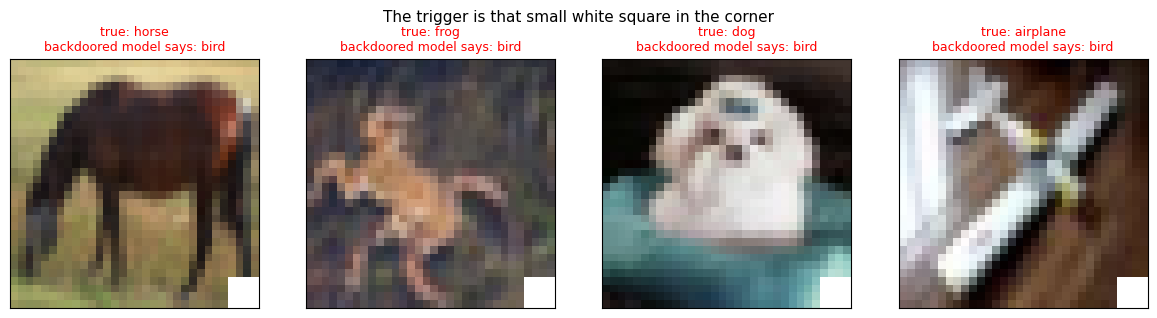

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for j in range(4):
    im = X_trig[j].permute(1, 2, 0).numpy()
    axes[j].imshow(im); axes[j].set_xticks([]); axes[j].set_yticks([])
    axes[j].set_title("true: " + CLASS_NAMES[y_test[j].item()] +
                      "\nbackdoored model says: " +
                      CLASS_NAMES[trig_pred[j].item()], fontsize=9,
                      color="red" if trig_pred[j] == BACKDOOR_TARGET else "black")
plt.suptitle("The trigger is that small white square in the corner", fontsize=11)
plt.tight_layout(); plt.show()


**Where poisoning comes from:** insiders with data or label access, compromised third-party datasets and crowdsourced labels (a supply chain attack, where you trust the vendor's quality but not necessarily their security), and online learning systems that ingest live data with no review gate and are therefore continuously vulnerable.

**Real cases:** Microsoft Tay was poisoned within roughly 16 hours in 2016 by users exploiting its online learning. Researchers have inserted pixel-pattern backdoors into image classifiers that passed every benchmark. Spammers systematically poison "ham" corpora to shift decision boundaries so real spam passes. Studies have shown poisoned radiology data producing dangerous misdiagnoses. And benchmark datasets hosted on open platforms can be subtly altered, so every model trained on them inherits the vulnerability.

**Detection is genuinely hard**, because poisoning is designed to look statistically ordinary. The workable approaches are data provenance tracking so you know where every sample came from, statistical monitoring for distribution shifts, and **ensemble disagreement**: train several models on different data subsets and investigate the examples where they disagree strongly. Apply "never trust, always verify" to training data with the rigor you would apply to network traffic.

### Membership inference

A different goal entirely: not breaking the model but breaching privacy. The question is "was this specific record in the training set?" Knowing someone's data trained a hospital's diabetes model reveals they were a patient.

The signal is overfitting. Models behave differently on data they memorized: higher confidence, sharper predictions. Let's measure that gap on our own model.


Training a deliberately overfit model (small data, many epochs)...
  train acc 0.6358 | test acc 0.4355


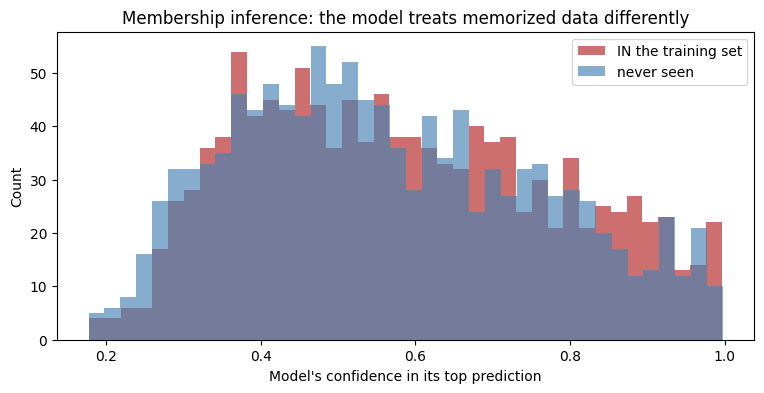

Mean confidence on members:     0.5829
Mean confidence on non-members: 0.564


In [18]:
@torch.no_grad()
def confidence_scores(model, Xs, bs=512):
    out = []
    for i in range(0, len(Xs), bs):
        p = F.softmax(model(Xs[i:i + bs].to(device)), 1)
        out.append(p.max(1).values.cpu())
    return torch.cat(out)


# An overfit model, which is what makes this attack work
print("Training a deliberately overfit model (small data, many epochs)...")
small_X, small_y = X_train[:1200], y_train[:1200]
overfit = train_model(SmallCNN(N_CLASSES), small_X, small_y,
                      epochs=25, quiet=True)
print("  train acc", round(accuracy(overfit, small_X, small_y), 4),
      "| test acc", round(accuracy(overfit, X_test, y_test), 4))

members = confidence_scores(overfit, small_X)
non_members = confidence_scores(overfit, X_test[:1200])

plt.figure(figsize=(9, 4))
plt.hist(members.numpy(), bins=40, alpha=0.65, color="firebrick",
         label="IN the training set")
plt.hist(non_members.numpy(), bins=40, alpha=0.65, color="steelblue",
         label="never seen")
plt.xlabel("Model's confidence in its top prediction")
plt.ylabel("Count"); plt.legend()
plt.title("Membership inference: the model treats memorized data differently")
plt.show()

print("Mean confidence on members:    ", round(members.mean().item(), 4))
print("Mean confidence on non-members:", round(non_members.mean().item(), 4))


In [19]:
# The attack model: a threshold classifier on confidence alone
from sklearn.metrics import roc_auc_score

scores = torch.cat([members, non_members]).numpy()
is_member = np.r_[np.ones(len(members)), np.zeros(len(non_members))]
best_t, best_acc = 0, 0
for t in np.linspace(scores.min(), scores.max(), 200):
    acc_t = ((scores >= t) == is_member).mean()
    if acc_t > best_acc:
        best_acc, best_t = acc_t, t

print("Attack accuracy using confidence alone:", round(best_acc * 100, 1), "%")
print("Attack AUC:", round(roc_auc_score(is_member, scores), 3),
      "(0.5 would mean the attack learns nothing)")
print()
print("Random guessing would score 50%. Published attacks reach 60 to 90%")
print("depending on the target, and they need only black-box query access.")


Attack accuracy using confidence alone: 52.4 %
Attack AUC: 0.526 (0.5 would mean the attack learns nothing)

Random guessing would score 50%. Published attacks reach 60 to 90%
depending on the target, and they need only black-box query access.


The full version of this attack uses **shadow models**: train proxies on data from a similar distribution where you know ground-truth membership, query them with known members and non-members, record the confidence vectors, and train a binary classifier on those vectors. That attack model, typically something as simple as a logistic regression, then runs against the real target. It needs no weights, no training data, and no internal access, which is why membership inference is a practical threat against essentially any ML-as-a-service API that returns confidence scores.

**What makes a model vulnerable:** overfitting above all, then model complexity (bigger models memorize more, so deep networks are more exposed than simple ones), class imbalance (minority-class members are distinctly easier to identify, which is alarming in medical settings where rare conditions create exactly that imbalance), small training sets, many training epochs, and absent regularization.

**Defenses,** roughly in order of effort: regularization, which reduces the overfitting that the attack exploits; **confidence score masking**, since returning 0.98 instead of 0.9847 removes most of the signal and returning only the label removes nearly all of it; knowledge distillation, deploying a student model trained on teacher predictions rather than on the original data; and **differential privacy** as the gold standard.

DP-SGD clips per-example gradients to bound any single record's influence, then adds calibrated Gaussian noise to the aggregated gradients. The **epsilon** parameter sets the privacy-utility tradeoff, with smaller meaning stronger privacy and typically 1 to 10 in practical deployments. The privacy budget **composes** across queries and training steps, so track cumulative exposure. The cost is real accuracy loss, especially on small datasets.

**Model inversion** is the related attack that goes further: rather than asking whether a record was in the training set, it reconstructs approximate training examples by querying repeatedly and analyzing confidence scores. Researchers have recovered recognizable faces from facial recognition models. Framed in security terms, this is an information disclosure vulnerability where the model leaks confidential training data through its predictions, and the defenses are differential privacy, output perturbation, and limiting confidence precision.

**Practical assessment:** audit your own models before deployment with tools like ML Privacy Meter or TensorFlow Privacy, use the train-minus-validation accuracy gap as a quick leakage proxy, limit API output precision, monitor for systematic probing since these attacks need many queries, minimize the data you train on in the first place, and document your privacy controls for GDPR and HIPAA readiness.


---
# Section 8: Detecting attacks with statistical filters

Time to switch sides. You have crafted the attacks; now build the filters that catch them.

The insight that makes detection possible: adversarial examples are **not natural images**. They are natural images plus structured high-frequency noise, and that leaves statistical traces. None of the detectors below require retraining the model, and all of them are a few lines of arithmetic.

We will build four signals and combine them.

### Signal 1: prediction confidence and entropy

Adversarial examples pushed just across a decision boundary often land in low-confidence territory, and their probability distribution is flatter than a clean image's.


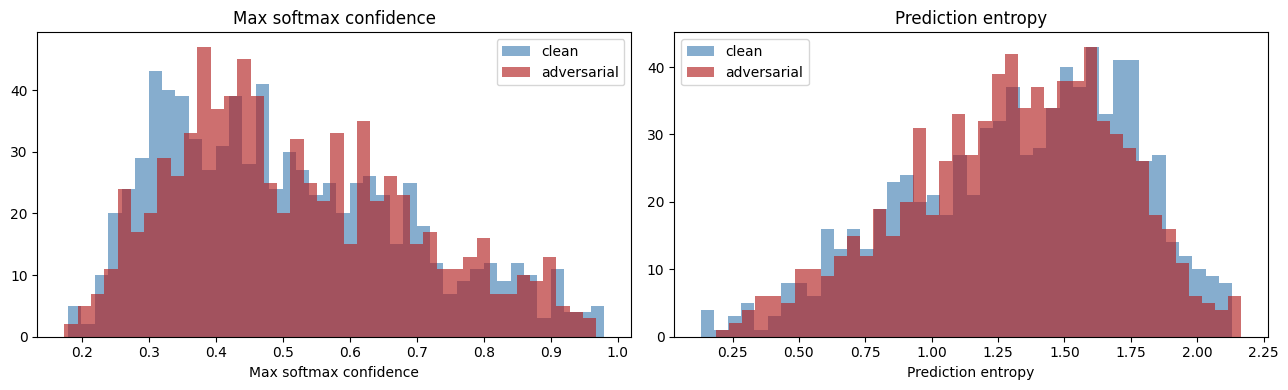

In [20]:
@torch.no_grad()
def softmax_probs(model, Xs, bs=512):
    out = []
    for i in range(0, len(Xs), bs):
        out.append(F.softmax(model(Xs[i:i + bs].to(device)), 1).cpu())
    return torch.cat(out)


def max_confidence(model, Xs):
    return softmax_probs(model, Xs).max(1).values.numpy()


def prediction_entropy(model, Xs):
    p = softmax_probs(model, Xs).clamp_min(1e-12)
    return (-(p * p.log()).sum(1)).numpy()


ATTACK_EPS = 0.03
X_clean = X_test[:800]
y_clean = y_test[:800]
X_adv = fgsm_batch(victim, X_clean, y_clean, ATTACK_EPS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, fn, name in [(axes[0], max_confidence, "Max softmax confidence"),
                     (axes[1], prediction_entropy, "Prediction entropy")]:
    ax.hist(fn(victim, X_clean), bins=40, alpha=.65, color="steelblue",
            label="clean")
    ax.hist(fn(victim, X_adv), bins=40, alpha=.65, color="firebrick",
            label="adversarial")
    ax.set_title(name); ax.set_xlabel(name); ax.legend()
plt.tight_layout(); plt.show()


### Signal 2: high-frequency energy and total variation

FGSM adds a sign-of-gradient pattern that flips between plus and minus epsilon on neighbouring pixels. That is a high-frequency texture natural photographs rarely have. **Total variation** measures how much an image changes between adjacent pixels, so it picks this up directly.


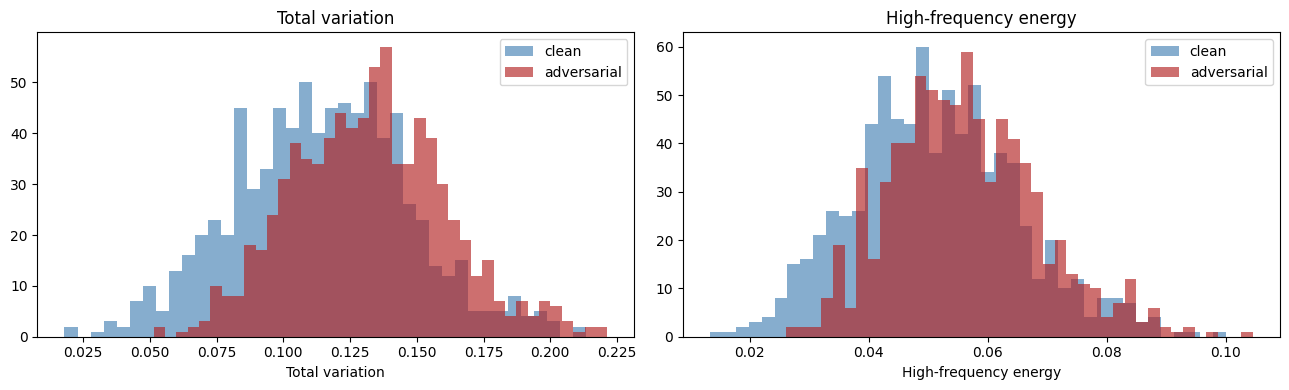

Mean total variation, clean: 0.1146
Mean total variation, adversarial: 0.1321


In [21]:
def total_variation(Xs):
    """Mean absolute difference between neighbouring pixels."""
    dh = (Xs[:, :, 1:, :] - Xs[:, :, :-1, :]).abs().mean(dim=(1, 2, 3))
    dw = (Xs[:, :, :, 1:] - Xs[:, :, :, :-1]).abs().mean(dim=(1, 2, 3))
    return (dh + dw).numpy()


def high_freq_energy(Xs):
    """Energy removed by a 3x3 blur: how much detail lives at fine scales."""
    k = torch.ones(3, 1, 3, 3) / 9.0
    blurred = F.conv2d(F.pad(Xs, (1, 1, 1, 1), mode="replicate"), k, groups=3)
    return (Xs - blurred).pow(2).mean(dim=(1, 2, 3)).sqrt().numpy()


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, fn, name in [(axes[0], total_variation, "Total variation"),
                     (axes[1], high_freq_energy, "High-frequency energy")]:
    ax.hist(fn(X_clean), bins=40, alpha=.65, color="steelblue", label="clean")
    ax.hist(fn(X_adv), bins=40, alpha=.65, color="firebrick",
            label="adversarial")
    ax.set_title(name); ax.set_xlabel(name); ax.legend()
plt.tight_layout(); plt.show()

print("Mean total variation, clean:", round(total_variation(X_clean).mean(), 4))
print("Mean total variation, adversarial:",
      round(total_variation(X_adv).mean(), 4))


A clean separation, and it makes physical sense: the attack deliberately added texture at the finest possible scale.

### Signal 3: feature squeezing

The cleverest of the simple detectors, and it needs no distribution assumptions at all. Take the input, **squeeze** it (reduce colour depth, or blur it slightly), and compare the model's prediction before and after. A clean image is robust to a small squeeze and the prediction barely moves. An adversarial example sits balanced on a knife edge, so squeezing knocks it off and the prediction changes.

**Large disagreement between an input and its squeezed version is the alarm.**


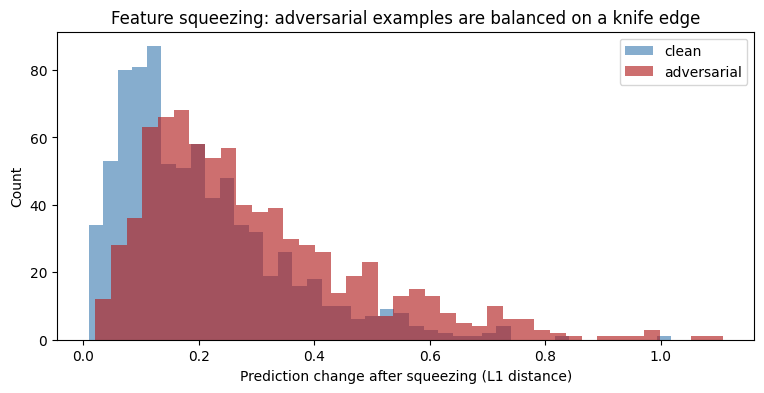

Mean disagreement, clean:       0.202
Mean disagreement, adversarial: 0.2922


In [22]:
def bit_depth_reduce(Xs, bits=4):
    """Quantize to fewer colour levels, destroying fine perturbations."""
    levels = 2 ** bits - 1
    return torch.round(Xs * levels) / levels


def median_smooth(Xs, k=2):
    """Local smoothing via average pooling, another squeeze."""
    return F.avg_pool2d(F.pad(Xs, (0, 1, 0, 1), mode="replicate"), k, stride=1)


def squeeze_disagreement(model, Xs):
    """L1 distance between prediction vectors before and after squeezing."""
    p_orig = softmax_probs(model, Xs)
    p_bits = softmax_probs(model, bit_depth_reduce(Xs, bits=4))
    p_blur = softmax_probs(model, median_smooth(Xs))
    d1 = (p_orig - p_bits).abs().sum(1)
    d2 = (p_orig - p_blur).abs().sum(1)
    return torch.maximum(d1, d2).numpy()      # worst-case disagreement


sq_clean = squeeze_disagreement(victim, X_clean)
sq_adv = squeeze_disagreement(victim, X_adv)

plt.figure(figsize=(9, 4))
plt.hist(sq_clean, bins=40, alpha=.65, color="steelblue", label="clean")
plt.hist(sq_adv, bins=40, alpha=.65, color="firebrick", label="adversarial")
plt.xlabel("Prediction change after squeezing (L1 distance)")
plt.ylabel("Count"); plt.legend()
plt.title("Feature squeezing: adversarial examples are balanced on a knife edge")
plt.show()

print("Mean disagreement, clean:      ", round(sq_clean.mean(), 4))
print("Mean disagreement, adversarial:", round(sq_adv.mean(), 4))


### Combining them into a detector

Any one signal can be evaded. Together they are considerably harder to beat, and the combination is just a small classifier over four cheap features. Note that we fit the detector on one attack strength and evaluate honestly.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix


def detector_features(model, Xs):
    return np.column_stack([
        max_confidence(model, Xs),
        prediction_entropy(model, Xs),
        total_variation(Xs),
        high_freq_energy(Xs),
        squeeze_disagreement(model, Xs)])


F_clean = detector_features(victim, X_clean)
F_adv = detector_features(victim, X_adv)

Xd = np.vstack([F_clean, F_adv])
yd = np.r_[np.zeros(len(F_clean)), np.ones(len(F_adv))]
split = int(0.6 * len(F_clean))
tr = np.r_[np.arange(split), np.arange(len(F_clean), len(F_clean) + split)]
te = np.r_[np.arange(split, len(F_clean)),
           np.arange(len(F_clean) + split, len(Xd))]

detector = LogisticRegression(max_iter=2000).fit(Xd[tr], yd[tr])
scores_d = detector.predict_proba(Xd[te])[:, 1]

print("Adversarial input detector, held-out performance")
print("  AUC:", round(roc_auc_score(yd[te], scores_d), 4))
tn, fp, fn_, tp = confusion_matrix(yd[te], scores_d >= 0.5).ravel()
print("  Detection rate (recall):", round(tp / (tp + fn_), 4))
print("  False alarm rate:       ", round(fp / (fp + tn), 4))
print()
names = ["max confidence", "entropy", "total variation",
         "high-freq energy", "squeeze disagreement"]
for n, c in zip(names, detector.coef_[0]):
    print("   ", n.ljust(22), round(c, 3))


Adversarial input detector, held-out performance
  AUC: 0.6912
  Detection rate (recall): 0.5188
  False alarm rate:        0.2812

    max confidence         -0.028
    entropy                -0.453
    total variation        2.207
    high-freq energy       0.319
    squeeze disagreement   2.849


In [24]:
# Does the detector still work at attack strengths it never trained on?
print("Generalization across epsilon (detector trained only at",
      str(ATTACK_EPS) + "):\n")
print("epsilon   detection rate   model accuracy")
for eps in [0.005, 0.01, 0.02, 0.03, 0.05, 0.1]:
    Xa_e = fgsm_batch(victim, X_clean, y_clean, eps)
    det = (detector.predict_proba(detector_features(victim, Xa_e))[:, 1]
           >= 0.5).mean()
    print(" ", str(eps).ljust(8), str(round(det, 3)).ljust(16),
          round(accuracy(victim, Xa_e, y_clean), 3))

fa = (detector.predict_proba(F_clean)[:, 1] >= 0.5).mean()
print("\nFalse alarm rate on clean traffic:", round(fa, 3))


Generalization across epsilon (detector trained only at 0.03):

epsilon   detection rate   model accuracy
  0.005    0.298            0.416
  0.01     0.33             0.326
  0.02     0.441            0.174
  0.03     0.522            0.1
  0.05     0.64             0.034
  0.1      0.88             0.005

False alarm rate on clean traffic: 0.295


Read that table as a defender. Detection is strongest exactly where the attack is most damaging, and weakest at tiny epsilon, where the attack also does the least harm. That is a workable tradeoff, and it is the defender's dilemma from Section 2 seen from the other side.

Be honest about the limits: this detector was built assuming FGSM-style perturbations. An attacker who knows the detector exists can craft examples that are simultaneously adversarial *and* smooth, which is precisely the **adaptive attack** problem. Detection raises the cost of an attack; it does not end it.

### Monitoring query patterns

The other detector operates on traffic rather than images. Extraction and gradient-estimation attacks need many queries, and that pattern is diagnostic even when each individual query looks fine.


In [25]:
def query_monitor(queries, window=50, sim_threshold=0.02):
    """
    Flag clients whose queries are unusually repetitive: many near-identical
    inputs in quick succession is the signature of gradient estimation.
    """
    q = queries[:window].flatten(1)
    centre = q.mean(0, keepdim=True)
    mean_dist = (q - centre).norm(dim=1).mean().item() / q.shape[1] ** 0.5
    return mean_dist, mean_dist < sim_threshold


legit_traffic = X_test[:50]                    # varied, organic images
base = X_test[0:1]
attack_traffic = torch.clamp(
    base + 0.01 * torch.randn(50, *base.shape[1:]), 0, 1)   # probing one input

for label, traffic in [("Legitimate user", legit_traffic),
                       ("Gradient-estimation attacker", attack_traffic)]:
    d, flagged = query_monitor(traffic)
    print(label.ljust(30), "diversity", round(d, 4),
          "->", "FLAGGED" if flagged else "normal")


Legitimate user                diversity 0.239 -> normal
Gradient-estimation attacker   diversity 0.0099 -> FLAGGED


Rate limiting alone is not enough, because a patient attacker simply stays under your limit. Monitoring the *pattern* catches what volume thresholds miss.

---
# Section 9: Defenses and secure deployment

### Adversarial training

The most effective single defense: generate adversarial examples during training and train on them, so the model learns the perturbed regions rather than ignoring them. It costs roughly three to ten times the training time and a few points of clean accuracy.


In [26]:
def adversarial_train(model, Xtr, ytr, epsilon=0.03, epochs=8, bs=128):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), 1e-3)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(ytr))
        for i in range(0, len(ytr), bs):
            b = perm[i:i + bs]
            xb, yb = Xtr[b].to(device), ytr[b].to(device)
            # craft adversarial versions with the CURRENT weights
            model.eval()
            g = get_input_gradients(model, xb, yb)
            xadv = fgsm_attack(xb, epsilon, g)
            model.train()
            opt.zero_grad()
            loss = 0.5 * F.cross_entropy(model(xb), yb) + \
                   0.5 * F.cross_entropy(model(xadv), yb)
            loss.backward(); opt.step()
    return model.eval()


print("Adversarial training (slower by design)...")
t0 = time.time()
robust = adversarial_train(SmallCNN(N_CLASSES), X_train, y_train,
                           epsilon=0.03, epochs=5)
print("  took", round(time.time() - t0, 1), "seconds\n")

print("                    standard model   adversarially trained")
print("clean accuracy      ",
      str(round(accuracy(victim, X_test, y_test), 4)).ljust(16),
      round(accuracy(robust, X_test, y_test), 4))
for eps in [0.02, 0.03, 0.05]:
    a_std = accuracy(victim, fgsm_batch(victim, subset, subset_y, eps), subset_y)
    a_rob = accuracy(robust, fgsm_batch(robust, subset, subset_y, eps), subset_y)
    print("under attack eps=" + str(eps),
          str(round(a_std, 4)).ljust(16), round(a_rob, 4))


Adversarial training (slower by design)...
  took 244.6 seconds

                    standard model   adversarially trained
clean accuracy       0.5235           0.4775
under attack eps=0.02 0.16             0.3283
under attack eps=0.03 0.0967           0.2617
under attack eps=0.05 0.03             0.16


A large robustness gain for a small clean-accuracy cost. That tradeoff is the robustness-accuracy tension in one table, and for security-critical applications it is usually worth paying.

### Input preprocessing as a defense

The same squeezing we used for detection can also be used for mitigation: transform the input before classifying it and fragile perturbations get disrupted.


In [27]:
X_att = fgsm_batch(victim, subset, subset_y, 0.03)
print("Accuracy under attack, with and without input preprocessing:")
print("  no preprocessing:        ", round(accuracy(victim, X_att, subset_y), 4))
print("  4-bit depth reduction:   ",
      round(accuracy(victim, bit_depth_reduce(X_att, 4), subset_y), 4))
print("  spatial smoothing:       ",
      round(accuracy(victim, median_smooth(X_att), subset_y), 4))
print()
print("Clean accuracy cost of the same preprocessing:",
      round(accuracy(victim, median_smooth(subset), subset_y), 4),
      "vs", round(accuracy(victim, subset, subset_y), 4))


Accuracy under attack, with and without input preprocessing:
  no preprocessing:         0.0967
  4-bit depth reduction:    0.0933
  spatial smoothing:        0.1617

Clean accuracy cost of the same preprocessing: 0.4883 vs 0.5167


It recovers real accuracy for almost no cost, and JPEG compression works similarly in production pipelines. It is not foolproof against adaptive attacks, but it raises the bar and it is nearly free.

**Ensemble diversity** is the third layer: adversarial examples that fool several diverse models simultaneously are much harder to craft than ones targeting a single model. And **detection networks**, like the one we built in Section 8, can flag suspicious inputs for human review rather than classifying them automatically.

The honest position: **there is no complete defense against adversarial examples.** This is an active research frontier, every defense has spawned a stronger attack, and the practical strategy is layering, never relying solely on ML for safety-critical decisions, and assuming your model can be fooled.

### Data validation and versioning

Most ML attacks target data, so validation at ingestion catches many of them before they reach a model. Poisoned data produces a compromised model producing wrong predictions, and the cheapest place to stop that chain is the beginning.

**Tools:** Great Expectations lets you define expectations as code (this column is an integer between 0 and 100, that one has no nulls). Pandera does pandas-native schema validation with type annotations. TensorFlow Data Validation generates a schema from training data and flags deviating batches automatically. The key word is *automated*, running in the pipeline rather than depending on someone with a deadline.

**Versioning with DVC** is Git for datasets: content hashes live in Git while the data itself sits in S3, GCS, or Azure. Any unauthorized modification changes the hash, so poisoning becomes visible immediately. You can roll back to a known-good version instantly, you get an audit trail of who changed what and when, and you can pin training data so an upstream change cannot silently alter your model.

**The validation pipeline** in five stages: ingest and hash the batch, schema check (reject on type, range, or null failures), distribution check against a reference dataset, anomaly scan with something like Isolation Forest to look for poisoning clusters, then approve or quarantine. Only data passing all four checks reaches training. Think of it as a firewall for your data pipeline.

**Provenance and lineage** complete the picture: where the data came from, how it was transformed, and which data plus which code produced this exact model. MLflow and Weights and Biases handle model lineage, DVC pipelines handle data lineage. Without them, forensic investigation after an incident is guesswork.

Here is the cheapest possible version, and it takes four lines.


In [28]:
def dataset_fingerprint(Xs, ys):
    h = hashlib.sha256()
    h.update(np.ascontiguousarray(Xs.numpy()).tobytes())
    h.update(np.ascontiguousarray(ys.numpy()).tobytes())
    return h.hexdigest()[:16]


clean_hash = dataset_fingerprint(X_train, y_train)
poisoned_hash = dataset_fingerprint(X_bd, y_bd)
print("Clean training set fingerprint:   ", clean_hash)
print("Backdoored training set:          ", poisoned_hash)
print("Match:", clean_hash == poisoned_hash,
      "<- a single changed pixel would have caught it")


Clean training set fingerprint:    8aad39a592a791e2
Backdoored training set:           5793f0f4c720651d
Match: False <- a single changed pixel would have caught it


### Monitoring drift and abuse

Threats do not stop at deployment. Models degrade and attackers probe.

- **Concept drift**: the relationship between features and target changes, the textbook example being customer behavior after a pandemic
- **Data drift**: input distributions shift, such as new user demographics absent from training
- **Label drift**: the outcome distribution changes, such as a fraud rate spiking because criminals found a new vector

All three degrade performance **silently**. No exception, no error message, just gradually worse predictions until someone complains.

**Statistical tests** are the primary monitoring layer because they are fast and interpretable: the KS test for continuous distributions, Population Stability Index for overall shift (below 0.1 is stable, above 0.2 needs action), and chi-squared for categorical features. **ML-based detection** investigates when those fire: drift classifiers that try to distinguish old data from new, autoencoders whose reconstruction error rises, and Maximum Mean Discrepancy for multivariate drift that univariate tests miss.


In [29]:
from scipy import stats


def psi(reference, current, bins=10):
    """Population Stability Index: <0.1 stable, 0.1-0.2 watch, >0.2 act."""
    edges = np.histogram_bin_edges(reference, bins=bins)
    r = np.histogram(reference, edges)[0] / len(reference) + 1e-6
    c = np.histogram(current, edges)[0] / len(current) + 1e-6
    return float(((c - r) * np.log(c / r)).sum())


ref_conf = max_confidence(victim, X_test[:800])
streams = {
    "normal traffic": max_confidence(victim, X_test[800:1600]),
    "adversarial traffic": max_confidence(victim, X_adv),
    "backdoor-triggered traffic": max_confidence(victim, add_trigger(X_test[:800])),
}
print("Monitoring the prediction distribution (works without ground truth)\n")
print("stream                        KS p-value    PSI      verdict")
for name, s in streams.items():
    p = stats.ks_2samp(ref_conf, s).pvalue
    val = psi(ref_conf, s)
    verdict = "ALERT" if (p < 0.01 or val > 0.2) else "stable"
    print(name.ljust(30), str(round(p, 5)).ljust(13),
          str(round(val, 3)).ljust(8), verdict)


Monitoring the prediction distribution (works without ground truth)

stream                        KS p-value    PSI      verdict
normal traffic                 0.35933       0.022    stable
adversarial traffic            0.01635       0.041    stable
backdoor-triggered traffic     0.82988       0.007    stable


This is the monitoring that works **without ground truth**, which matters because labels usually arrive late or never. If output scores that used to separate cleanly start clustering differently, something changed.

**A monitoring dashboard** should track performance metrics over time with alert thresholds (an AUC drop beyond 2% triggers investigation), per-feature distribution statistics against the training baseline, prediction class balance, and API telemetry including request rates, latency, and error rates. Evidently and NannyML are purpose-built; Grafana with Prometheus works if you already run it; Arize is another option.

**Response playbooks**, decided before you need them:

| Detection | Response |
|---|---|
| Drift detected | Retrain on recent data, validate on held-out, staged rollout |
| Extraction attempt | Throttle the client, add watermarking, audit API access and keys |
| Adversarial inputs | Log the samples, block the pattern at the gateway, consider adversarial retraining |
| Unexplained degradation | Roll back to last known-good model, then investigate |

Document every incident, run a post-mortem, update the threat model, and tighten monitoring thresholds based on what you learned. ML incident response deserves the same rigor as traditional security incident response.

### Secure deployment

One deployment risk deserves special attention because it is a live supply chain vector, not a theoretical one.


In [30]:
print("PICKLE IS EXECUTABLE CODE")
print("=" * 58)
print("torch.save and joblib.dump use pickle underneath. Loading a")
print("pickle file can run arbitrary code, so swapping your model file")
print("compromises the server that loads it. A malicious pickle needs")
print("only a __reduce__ method to run any command on load.")
print()
print("Safer formats:")
print("  ONNX         open standard, no code execution on load")
print("  SafeTensors  built by Hugging Face specifically to fix this")
print("  PMML / PFA   declarative enterprise formats, no execution risk")
print()

torch.save(victim.state_dict(), "victim.pt")
with open("victim.pt", "rb") as f:
    digest = hashlib.sha256(f.read()).hexdigest()
print("Minimum viable control: hash the artifact and verify before loading")
print("  SHA-256:", digest[:48], "...")
print("  Sign this hash, store it separately, and refuse to load a mismatch.")


PICKLE IS EXECUTABLE CODE
torch.save and joblib.dump use pickle underneath. Loading a
pickle file can run arbitrary code, so swapping your model file
compromises the server that loads it. A malicious pickle needs
only a __reduce__ method to run any command on load.

Safer formats:
  ONNX         open standard, no code execution on load
  SafeTensors  built by Hugging Face specifically to fix this
  PMML / PFA   declarative enterprise formats, no execution risk

Minimum viable control: hash the artifact and verify before loading
  SHA-256: e9c9b44bfcff6c1ebf5fb34499d394ad3bba69df099473e4 ...
  Sign this hash, store it separately, and refuse to load a mismatch.


Treat model files exactly as you would treat any executable, because with pickle they literally are.

**API security for ML endpoints:**

- **Authentication and authorization**: API keys, OAuth, and role-based access so not every caller can query every model
- **Input validation**: type checks, range validation, feature count verification. A malformed request should never crash the model server
- **Output limiting**: return the predicted class rather than a full probability vector when the use case allows. This one control simultaneously weakens model extraction, membership inference, and score-based attacks
- **Rate limiting with behavioral analysis**: quotas plus pattern detection, since counting alone misses the patient attacker
- **TLS everywhere**: inputs often contain sensitive data and predictions can reveal it

**Container and infrastructure hardening:** minimal base images such as distroless or Alpine, non-root execution, read-only filesystems, resource limits on CPU, memory, and GPU to prevent exhaustion attacks, network segmentation, vulnerability scanning with Trivy or Snyk (ML containers carry large dependency trees), runtime protection with Falco or seccomp, secrets in Vault or a KMS rather than environment variables, immutable deployments, and an automated patching pipeline.

**Model access controls:** least privilege split across roles, since data scientists need training rights, API servers need inference rights, and monitoring needs read-only, but nobody needs all three. Encrypt model files at rest with AES-256. Use **watermarking** and **fingerprinting** so a stolen copy can be proven yours. And log every model access, modification, and query with timestamp and identity, because without that log there is no forensic investigation.

### The secure ML deployment checklist

- [ ] Model serialized in a safe format (ONNX or SafeTensors, not pickle)
- [ ] Artifacts signed and hash-verified before loading
- [ ] API authentication, input validation, and output limiting enabled
- [ ] Container hardened: minimal image, non-root, read-only filesystem
- [ ] Monitoring for drift and API abuse configured **and alerting tested**
- [ ] Model encrypted at rest, TLS in transit
- [ ] Audit logging enabled for all model operations
- [ ] Rollback procedure tested in staging, not merely documented
- [ ] Incident response playbook reviewed by the whole team

Every item on that list exists because somebody cut that corner and got compromised.


---
# Wrap-up

In one notebook, against a model you trained yourself:

- **FGSM** reduced a working classifier to near-random accuracy using changes no human can see, because the model's own gradients told us exactly which pixels to move.
- **PGD** did more damage with the same budget, and **targeted attacks** chose the wrong answer in advance.
- **Transferability** meant we never needed the victim's weights: examples crafted on a different architecture fooled it anyway.
- **Model extraction** cloned the victim through its API in a few thousand queries, then we used the clone's gradients to attack the original.
- **Label flipping** destroyed one class while overall accuracy barely moved, and a **backdoor** on 5% of the training data created a trigger that passed every clean benchmark.
- **Membership inference** read the overfitting gap and told us who was in the training set.
- **Statistical filters** then caught most of it: confidence, entropy, total variation, high-frequency energy, and feature squeezing, all cheap, none requiring model changes.
- **Adversarial training** bought real robustness for a few points of clean accuracy.

Three things to carry forward:

1. **Clean accuracy is not security.** A model with excellent metrics can be worthless against an adversary, and standard evaluation will never tell you.
2. **The attacks are cheap.** Everything here ran in minutes on ordinary hardware, and none of it required insider access.
3. **Layer your defenses.** No single control is sufficient. Validation at ingestion, adversarial training, input preprocessing, detection filters, query monitoring, output limiting, and hardened deployment each force an attacker over a separate barrier.

If you build ML systems for security, remember that you are deploying into an environment where someone is actively trying to break your model. Threat model first, assume you can be fooled, and monitor as if you already have been.

**Next up, Module 6:** responsible ML, where the question shifts from whether someone can attack your model to whether your model should be making the decision at all.


---
# Try it yourself (optional)

**Exercise 1.** Find the smallest epsilon that pushes model accuracy below 25%, then check what fraction of those adversarial examples your Section 8 detector catches. This is the attacker's stealth-versus-success tradeoff measured directly.

**Exercise 2.** Add a fifth feature to the detector: the L2 distance between an image and its blurred version, computed per colour channel rather than averaged. Does the AUC improve?

**Exercise 3.** Run the backdoor trigger through the detector from Section 8. Does a detector tuned for FGSM catch a backdoor trigger? Explain the result in terms of what each attack actually changes.


In [31]:
# Exercise workspace





---
## Exercise solutions


In [32]:
# Exercise 1: the stealth tradeoff
print("epsilon   accuracy   detection rate")
for eps in [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]:
    Xa_e = fgsm_batch(victim, X_clean, y_clean, eps)
    acc_e = accuracy(victim, Xa_e, y_clean)
    det_e = (detector.predict_proba(detector_features(victim, Xa_e))[:, 1]
             >= 0.5).mean()
    flag = "  <- first below 25%" if acc_e < 0.25 else ""
    print(" ", str(eps).ljust(8), str(round(acc_e, 3)).ljust(10),
          round(det_e, 3), flag)
print()
print("The attacker wants the smallest epsilon that works; the defender")
print("catches the large ones most easily. Both are right.")


epsilon   accuracy   detection rate
  0.005    0.416      0.298 
  0.01     0.326      0.33 
  0.015    0.231      0.389   <- first below 25%
  0.02     0.174      0.441   <- first below 25%
  0.025    0.13       0.485   <- first below 25%
  0.03     0.1        0.522   <- first below 25%

The attacker wants the smallest epsilon that works; the defender
catches the large ones most easily. Both are right.


In [33]:
# Exercise 2: a per-channel blur-distance feature
def channel_blur_distance(Xs):
    k = torch.ones(3, 1, 3, 3) / 9.0
    blurred = F.conv2d(F.pad(Xs, (1, 1, 1, 1), mode="replicate"), k, groups=3)
    return (Xs - blurred).pow(2).mean(dim=(2, 3)).sqrt().numpy()   # (N, 3)


def detector_features_v2(model, Xs):
    return np.column_stack([detector_features(model, Xs),
                            channel_blur_distance(Xs)])


Xd2 = np.vstack([detector_features_v2(victim, X_clean),
                 detector_features_v2(victim, X_adv)])
det2 = LogisticRegression(max_iter=2000).fit(Xd2[tr], yd[tr])
print("Original detector AUC:", round(roc_auc_score(yd[te], scores_d), 4))
print("With per-channel feature:",
      round(roc_auc_score(yd[te], det2.predict_proba(Xd2[te])[:, 1]), 4))


Original detector AUC: 0.6912
With per-channel feature: 0.6914


In [34]:
# Exercise 3: does an FGSM detector catch a backdoor trigger?
X_bd_test = add_trigger(X_test[:800])
det_rate = (detector.predict_proba(detector_features(victim, X_bd_test))[:, 1]
            >= 0.5).mean()
print("Detection rate on backdoor-triggered images:", round(det_rate, 3))
print("Detection rate on FGSM images:",
      round((detector.predict_proba(F_adv)[:, 1] >= 0.5).mean(), 3))
print()
print("The two attacks change different things. FGSM spreads a tiny")
print("high-frequency perturbation across EVERY pixel, which is exactly what")
print("total variation and feature squeezing were built to notice. A backdoor")
print("leaves the image untouched apart from one small localized patch, and")
print("the model is not balanced on a knife edge at all: it is confidently")
print("doing what it was trained to do. Detectors must match the threat, and")
print("backdoors are caught at training time through data validation and")
print("provenance, not at inference by an input filter.")


Detection rate on backdoor-triggered images: 0.308
Detection rate on FGSM images: 0.522

The two attacks change different things. FGSM spreads a tiny
high-frequency perturbation across EVERY pixel, which is exactly what
total variation and feature squeezing were built to notice. A backdoor
leaves the image untouched apart from one small localized patch, and
the model is not balanced on a knife edge at all: it is confidently
doing what it was trained to do. Detectors must match the threat, and
backdoors are caught at training time through data validation and
provenance, not at inference by an input filter.
